In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


In [4]:
df = pd.read_csv("/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv",
                 encoding='windows-1252')

print("Dataset Loaded!")
print(f"Shape: {df.shape}")
df.head()

Dataset Loaded!
Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== INFO ===")
df.info()

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())

=== SHAPE ===
(9994, 21)

=== COLUMNS ===
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

=== DATA TYPES ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== FIRST 5 ROWS ===
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/201

In [6]:
# Missing Values
print("=== MISSING VALUES ===")
print(df.isnull().sum())
df.dropna(inplace=True)

# Duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Fix Data Types
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Feature Engineering
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Ship Days']     = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

print("\nCleaning Done! Shape:", df.shape)

=== MISSING VALUES ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows: 0

Cleaning Done! Shape: (9994, 26)


In [7]:
print("=== SALES SUMMARY ===")
print(df[['Sales','Profit','Discount','Quantity','Profit Margin']].describe().round(2))

print("\n=== SALES BY CATEGORY ===")
print(df.groupby('Category')[['Sales','Profit']].sum().round(2))

print("\n=== SALES BY REGION ===")
print(df.groupby('Region')[['Sales','Profit']].sum().round(2))

print("\n=== SALES BY SEGMENT ===")
print(df.groupby('Segment')[['Sales','Profit']].sum().round(2))

=== SALES SUMMARY ===
          Sales   Profit  Discount  Quantity  Profit Margin
count   9994.00  9994.00   9994.00   9994.00        9994.00
mean     229.86    28.66      0.16      3.79          12.03
std      623.25   234.26      0.21      2.23          46.68
min        0.44 -6599.98      0.00      1.00        -275.00
25%       17.28     1.73      0.00      2.00           7.50
50%       54.49     8.67      0.20      3.00          27.00
75%      209.94    29.36      0.20      5.00          36.25
max    22638.48  8399.98      0.80     14.00          50.00

=== SALES BY CATEGORY ===
                     Sales     Profit
Category                             
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95

=== SALES BY REGION ===
             Sales     Profit
Region                       
Central  501239.89   39706.36
East     678781.24   91522.78
South    391721.90   46749.43
West     725457.82  108418.45

=== SALES BY SE

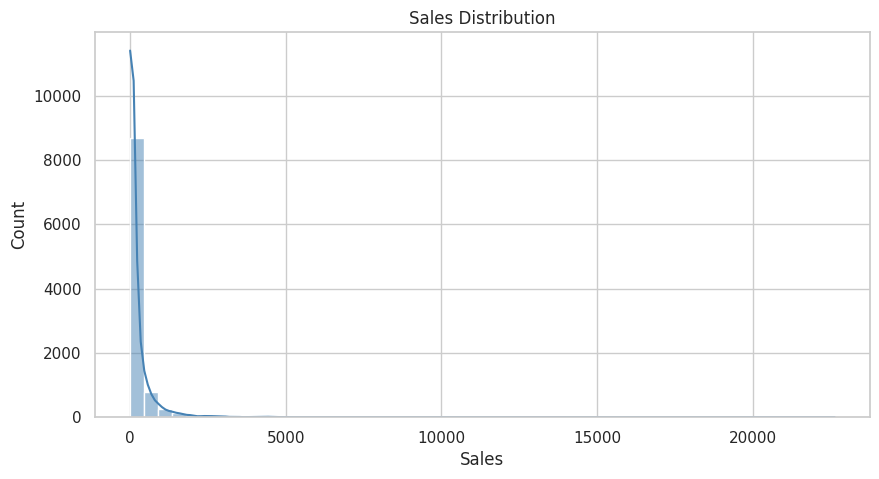

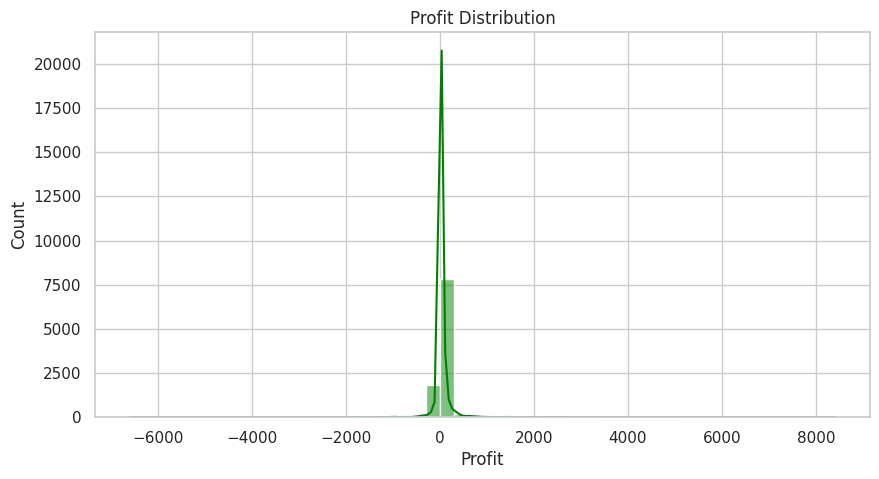

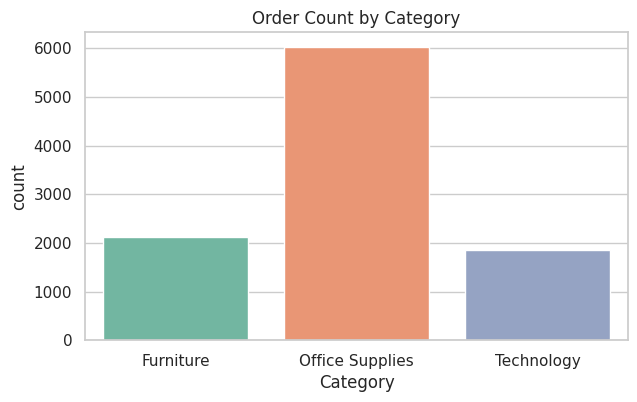

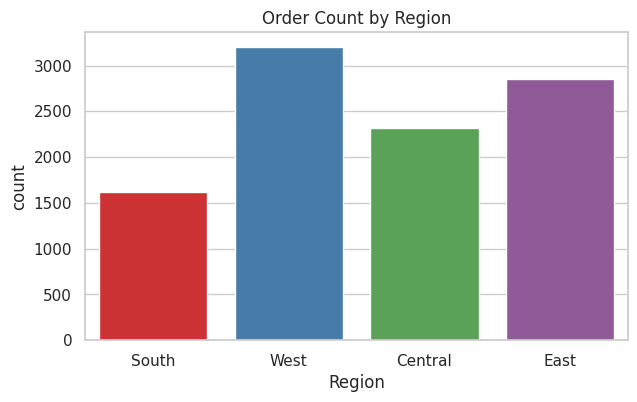

In [8]:
# Sales Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'], bins=50, kde=True, color='steelblue')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.savefig('sales_distribution.png', dpi=150)
plt.show()

# Profit Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Profit'], bins=50, kde=True, color='green')
plt.title('Profit Distribution')
plt.savefig('profit_distribution.png', dpi=150)
plt.show()

# Category Count
plt.figure(figsize=(7,4))
sns.countplot(x='Category', data=df, palette='Set2')
plt.title('Order Count by Category')
plt.savefig('category_count.png', dpi=150)
plt.show()

# Region Count
plt.figure(figsize=(7,4))
sns.countplot(x='Region', data=df, palette='Set1')
plt.title('Order Count by Region')
plt.savefig('region_count.png', dpi=150)
plt.show()

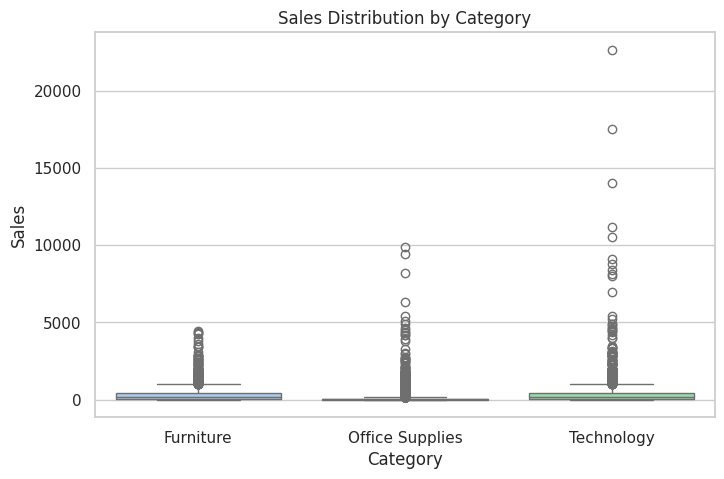

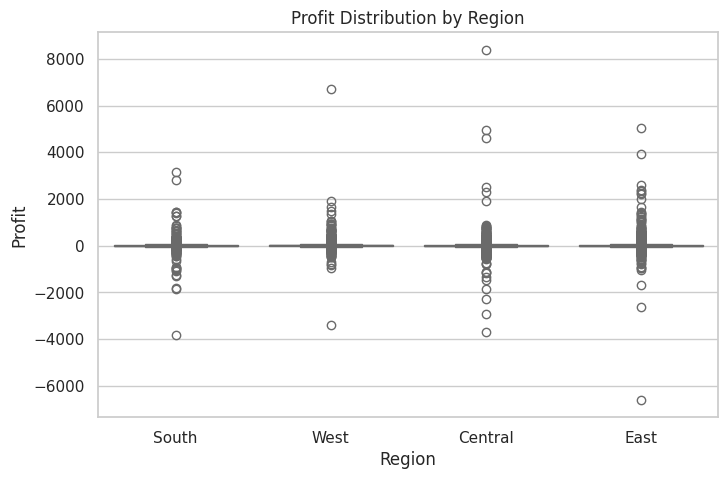

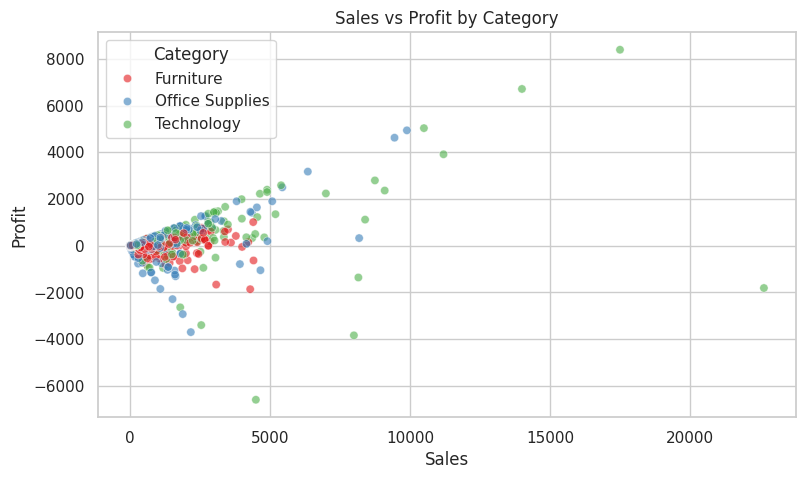

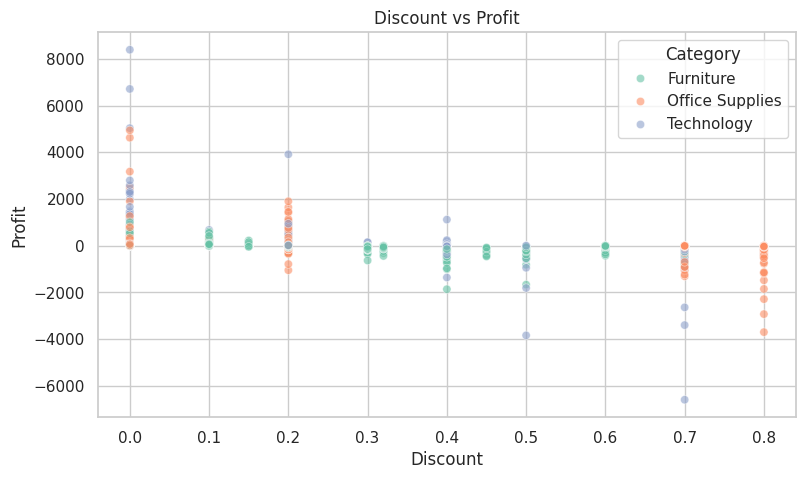

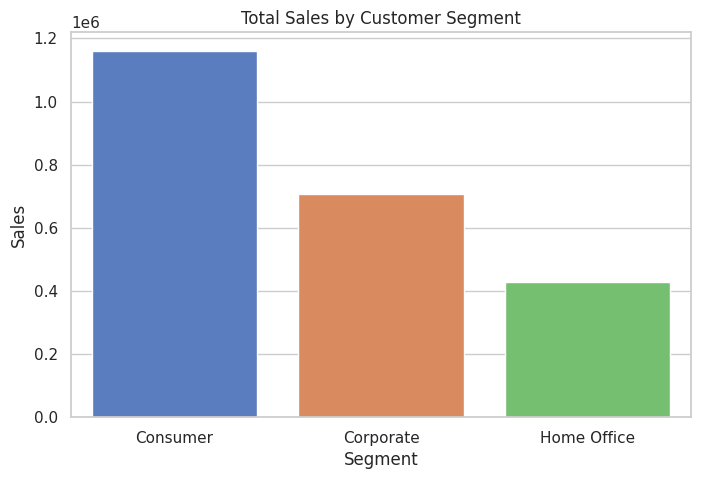

In [9]:
# Sales by Category
plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Sales', data=df, palette='pastel')
plt.title('Sales Distribution by Category')
plt.savefig('sales_by_category.png', dpi=150)
plt.show()

# Profit by Region
plt.figure(figsize=(8,5))
sns.boxplot(x='Region', y='Profit', data=df, palette='Set3')
plt.title('Profit Distribution by Region')
plt.savefig('profit_by_region.png', dpi=150)
plt.show()

# Sales vs Profit
plt.figure(figsize=(9,5))
sns.scatterplot(x='Sales', y='Profit', hue='Category', data=df, alpha=0.6, palette='Set1')
plt.title('Sales vs Profit by Category')
plt.savefig('sales_vs_profit.png', dpi=150)
plt.show()

# Discount vs Profit
plt.figure(figsize=(9,5))
sns.scatterplot(x='Discount', y='Profit', hue='Category', data=df, alpha=0.6, palette='Set2')
plt.title('Discount vs Profit')
plt.savefig('discount_vs_profit.png', dpi=150)
plt.show()

# Sales by Segment
plt.figure(figsize=(8,5))
seg = df.groupby('Segment')['Sales'].sum().reset_index()
sns.barplot(x='Segment', y='Sales', data=seg, palette='muted')
plt.title('Total Sales by Customer Segment')
plt.savefig('sales_by_segment.png', dpi=150)
plt.show()

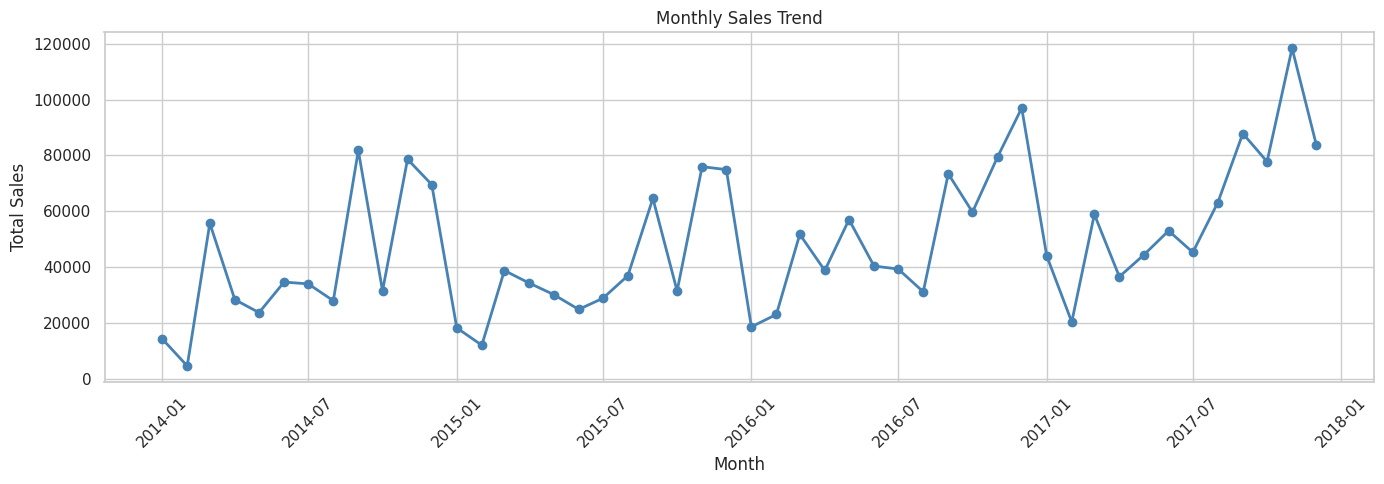

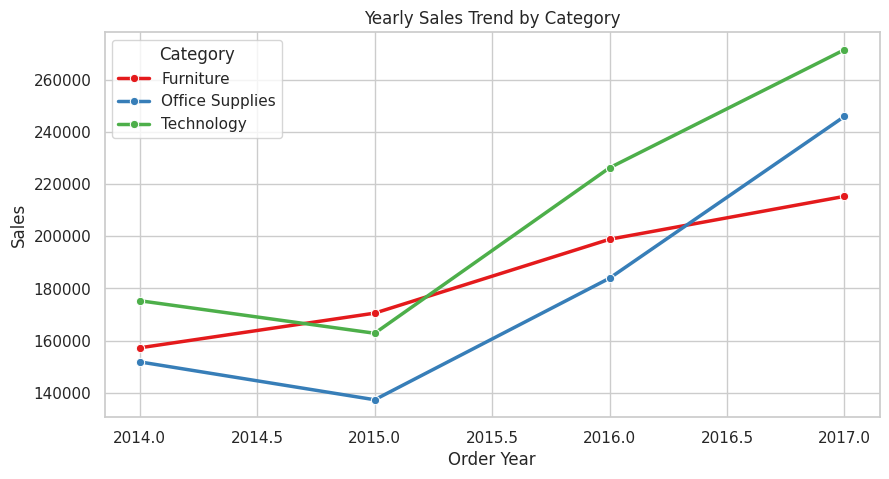

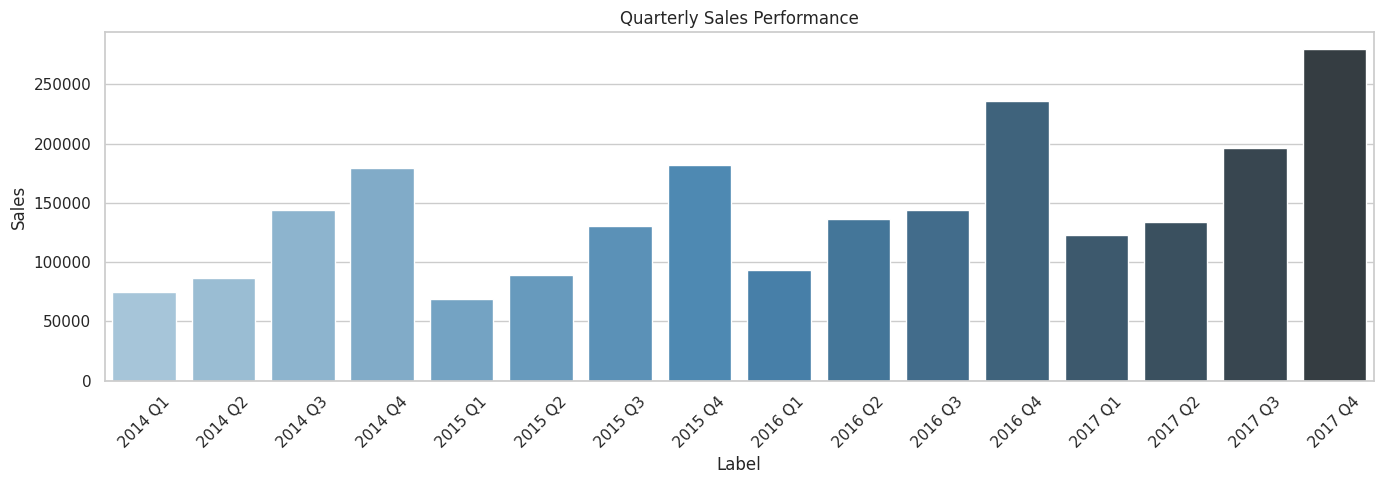

In [10]:
# Monthly Sales Trend
monthly = df.groupby(['Order Year','Order Month'])['Sales'].sum().reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Order Year','Order Month']].assign(day=1).rename(
    columns={'Order Year':'year','Order Month':'month'}))

plt.figure(figsize=(14,5))
plt.plot(monthly['Period'], monthly['Sales'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()

# Yearly Sales by Category
yearly_cat = df.groupby(['Order Year','Category'])['Sales'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(x='Order Year', y='Sales', hue='Category', data=yearly_cat,
             marker='o', palette='Set1', linewidth=2.5)
plt.title('Yearly Sales Trend by Category')
plt.savefig('yearly_category_trend.png', dpi=150)
plt.show()

# Quarterly Sales
quarterly = df.groupby(['Order Year','Order Quarter'])['Sales'].sum().reset_index()
quarterly['Label'] = quarterly['Order Year'].astype(str) + ' Q' + quarterly['Order Quarter'].astype(str)
plt.figure(figsize=(14,5))
sns.barplot(x='Label', y='Sales', data=quarterly, palette='Blues_d')
plt.title('Quarterly Sales Performance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('quarterly_sales.png', dpi=150)
plt.show()

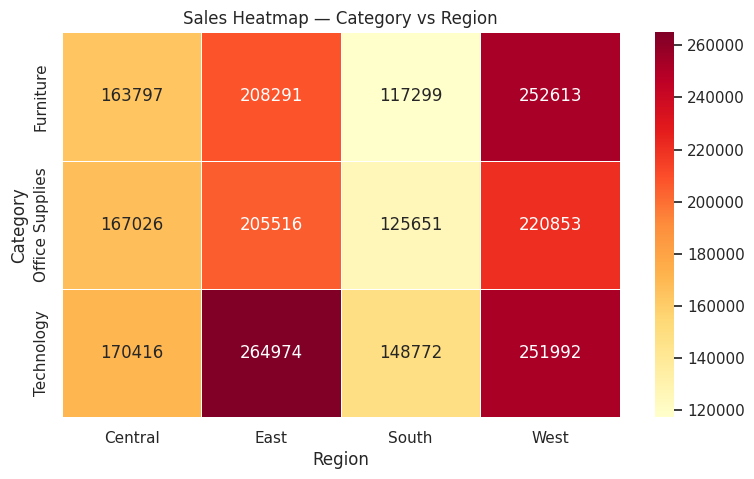

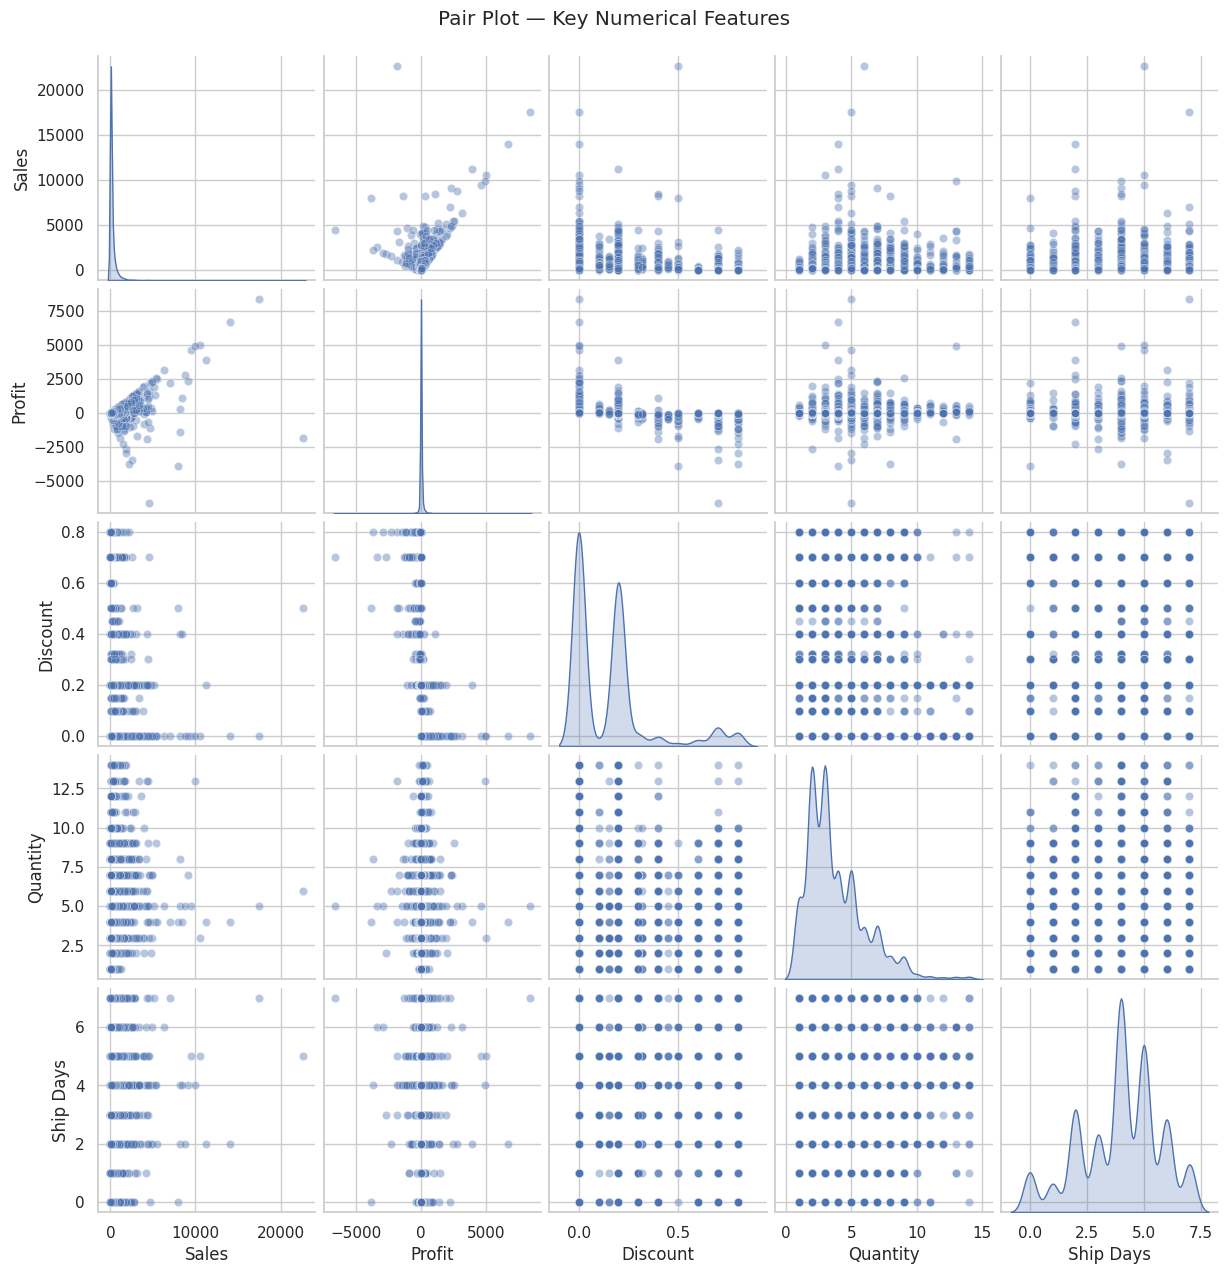

In [11]:
# Heatmap: Sales by Category and Region
pivot = df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')
plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Sales Heatmap — Category vs Region')
plt.savefig('sales_heatmap_cat_region.png', dpi=150)
plt.show()

# Pair Plot
pair_cols = ['Sales','Profit','Discount','Quantity','Ship Days']
sns.pairplot(df[pair_cols], diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle('Pair Plot — Key Numerical Features', y=1.02)
plt.savefig('pairplot.png', dpi=150)
plt.show()

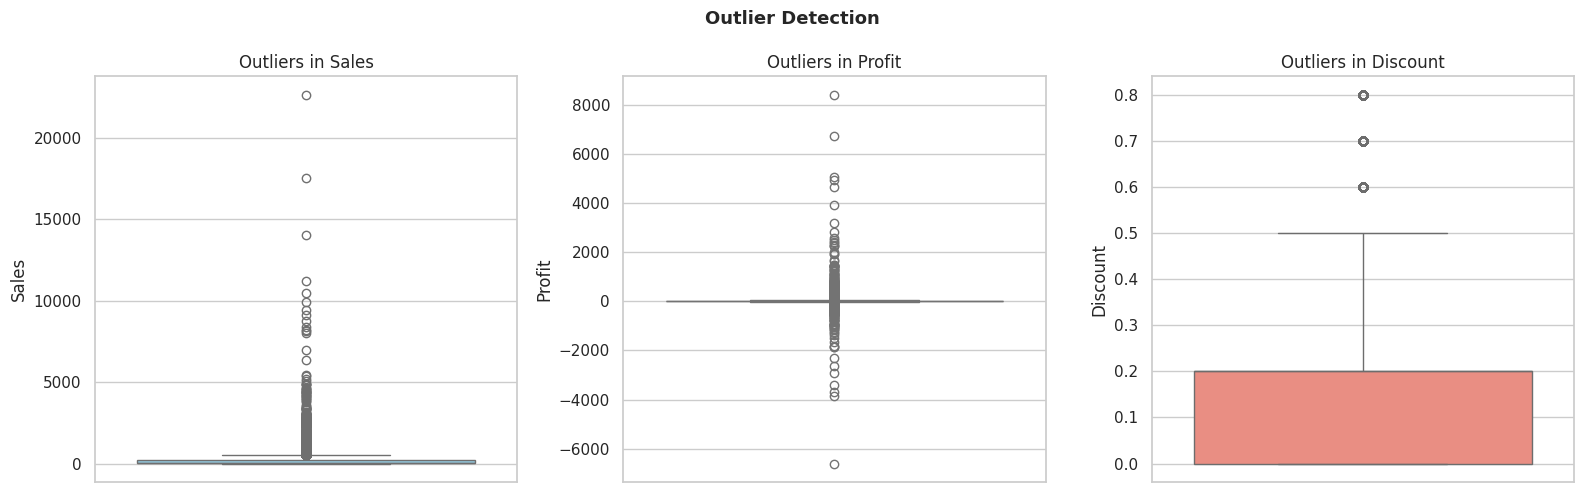

Outliers in 'Sales': 1167
Outliers in 'Profit': 1881
Outliers in 'Discount': 856


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.boxplot(y=df['Sales'],    ax=axes[0], color='skyblue')
axes[0].set_title('Outliers in Sales')

sns.boxplot(y=df['Profit'],   ax=axes[1], color='lightgreen')
axes[1].set_title('Outliers in Profit')

sns.boxplot(y=df['Discount'], ax=axes[2], color='salmon')
axes[2].set_title('Outliers in Discount')

plt.suptitle('Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers.png', dpi=150)
plt.show()

for col in ['Sales','Profit','Discount']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"Outliers in '{col}': {len(out)}")

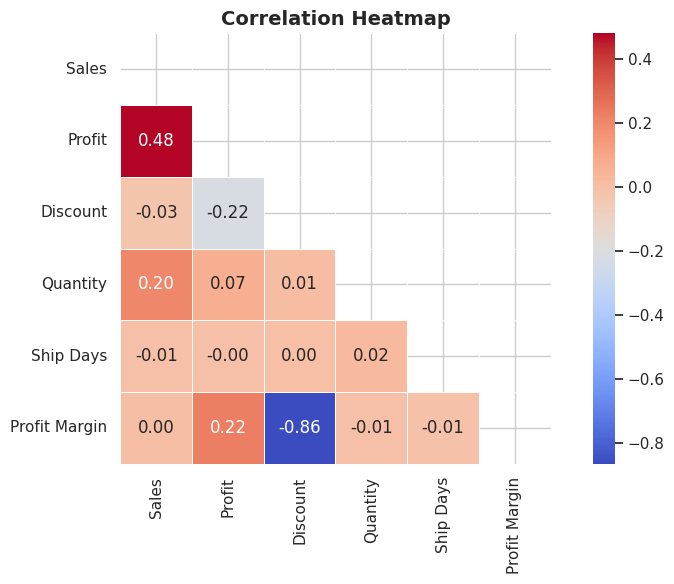


=== Correlation with Sales ===
Sales            1.000000
Profit           0.479064
Quantity         0.200795
Profit Margin    0.003444
Ship Days       -0.007354
Discount        -0.028190
Name: Sales, dtype: float64


In [13]:
num_df = df[['Sales','Profit','Discount','Quantity','Ship Days','Profit Margin']]
corr   = num_df.corr()

plt.figure(figsize=(9,6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("\n=== Correlation with Sales ===")
print(corr['Sales'].sort_values(ascending=False))

In [14]:
features = ['Quantity','Discount','Ship Days','Order Month',
            'Order Year','Order Quarter']

le = LabelEncoder()
df['Category_enc']     = le.fit_transform(df['Category'])
df['Region_enc']       = le.fit_transform(df['Region'])
df['Segment_enc']      = le.fit_transform(df['Segment'])
df['Sub-Category_enc'] = le.fit_transform(df['Sub-Category'])

ml_features = features + ['Category_enc','Region_enc',
                           'Segment_enc','Sub-Category_enc']

X = df[ml_features]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}")
print(f"Test size : {X_test.shape}")

Train size: (7995, 10)
Test size : (1999, 10)


In [15]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [16]:
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== RANDOM FOREST RESULTS ===")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

=== RANDOM FOREST RESULTS ===
MAE  : 220.97
RMSE : 692.57
R²   : 0.1880


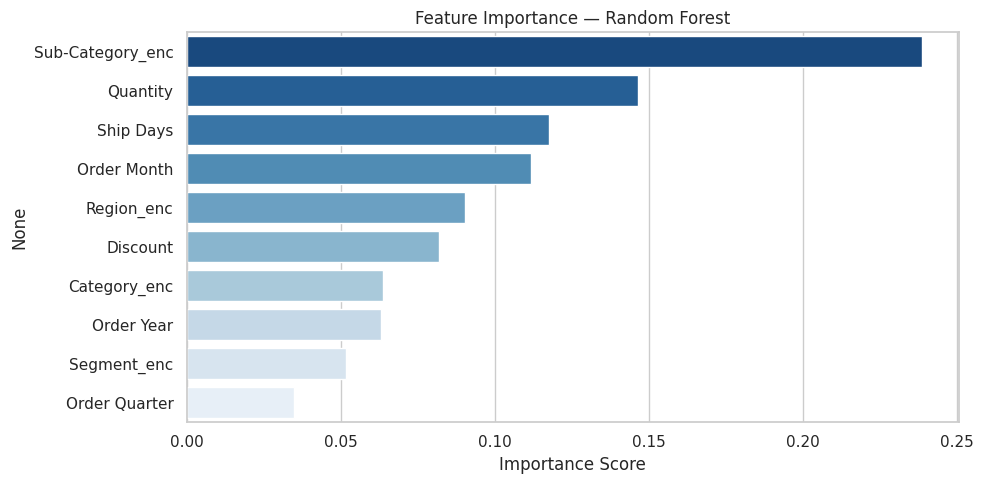


Top Features:
Sub-Category_enc    0.238550
Quantity            0.146560
Ship Days           0.117484
Order Month         0.111898
Region_enc          0.090395
Discount            0.081831
Category_enc        0.063560
Order Year          0.062990
Segment_enc         0.051819
Order Quarter       0.034912
dtype: float64


In [17]:
importances = pd.Series(rf_model.feature_importances_, index=ml_features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop Features:")
print(importances)

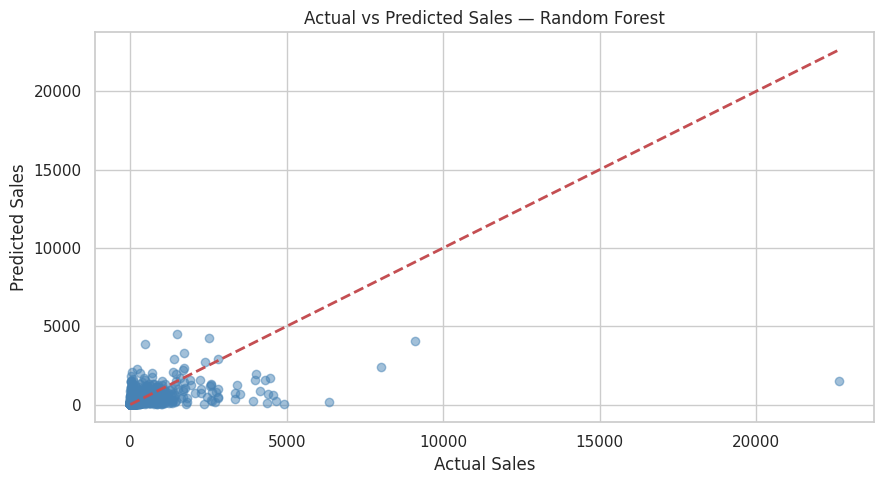

In [18]:
plt.figure(figsize=(9,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales — Random Forest')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

In [19]:
print("""
============================================================
         KEY BUSINESS INSIGHTS & RECOMMENDATIONS
============================================================

1. Technology leads in Sales & Profit.
2. High discounts (>20%) cause negative profit — cap them.
3. West region performs best; Central needs attention.
4. Q4 consistently shows sales peaks every year.
5. Consumer segment drives volume; Corporate drives margin.
6. Random Forest shows Sub-Category & Quantity as top predictors.

============================================================
""")


         KEY BUSINESS INSIGHTS & RECOMMENDATIONS

1. Technology leads in Sales & Profit.
2. High discounts (>20%) cause negative profit — cap them.
3. West region performs best; Central needs attention.
4. Q4 consistently shows sales peaks every year.
5. Consumer segment drives volume; Corporate drives margin.
6. Random Forest shows Sub-Category & Quantity as top predictors.


